## Imports

In [1]:
import geomstats.backend as gs
import karateclub as kc
import matplotlib.pyplot as plt
import networkx as nx
from networkx.drawing.nx_pydot import graphviz_layout
import numpy as np
import os
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import pydot
import random
import warnings

from geomstats.geometry.stratified.graph_space import GraphSpace
from geomstats.learning.aac import AAC
from plotly.subplots import make_subplots
from reeb_utils import do_reeb_for_start_end, do_reeb_for_explore_node, extract_tree_features, plot_treeb
from scipy.stats import pearsonr
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold


warnings.filterwarnings("ignore")
pd.options.mode.chained_assignment = None

## Load data

In [2]:
# load data into dataframe
df = pd.read_csv("data/MLINDIV_train_full.csv")

test_df = df[df["eprocs"].str.contains("Test")]

test_df["subj_mean_acc"] = test_df.groupby("Subject")["accuracy"].transform("mean")
test_df["path_mean_acc"] = test_df.groupby(["StartAt", "EndAt"])["accuracy"].transform("mean")

test_df['quartile'] = (
    pd.qcut(test_df['subj_mean_acc'], 4, labels=[1, 2, 3, 4])
)

test_df["path_mean_acc_by_Q"] = test_df.groupby(["StartAt", "EndAt", "quartile"])["accuracy"].transform("mean")

## Generate all test-path Flow Trees

In [21]:
## BY PATH
flow_trees = []
paths = []
accs = []
for (start_node, end_node), group in test_df.groupby(["StartAt", "EndAt"]):
    G = do_reeb_for_start_end(test_df, start_node, end_node, 0, use_turns=False) # 0 means all quartiles
    flow_trees.append(G)
    accs.append(group["path_mean_acc"].iloc[0])
    paths.append((start_node, end_node))

# select_made

accs = np.array(accs)

## Identify backbones

In [73]:
def get_heaviest_path(tree, root):
    root = root + "_0"
    
    # Get all leaves (nodes with degree 1, excluding the root)
    # leaves = [node for node in tree.nodes() if tree.degree(node) == 1 and node != root]
    leaves = [node for node in tree.nodes() if tree.nodes[node].get("color", "white") in ["yellow", "green"]]
    
    def dfs(node, current_path, current_weight):
        nonlocal max_weight, heaviest_path
        
        # If we're at a leaf (degree 1 and not root)
        if node in leaves:
            if current_weight > max_weight:
                max_weight = current_weight
                heaviest_path = current_path.copy()
            return
            
        # Explore all children
        for neighbor in tree.neighbors(node):
            if neighbor not in current_path:  # Avoid cycles
                edge_weight = tree[node][neighbor]['weight']
                current_path.append(neighbor)
                dfs(neighbor, current_path, current_weight + edge_weight)
                current_path.pop()
    
    max_weight = float('-inf')
    heaviest_path = None
    dfs(root, [root], 0)
    
    return heaviest_path, max_weight, [tree[heaviest_path[i]][heaviest_path[i+1]]['weight'] for i in range(len(heaviest_path)-1)]

flow_tree_dict = {}
for path, flow_tree, acc in zip(paths, flow_trees, accs):
    # print("Finding backbone for", path)
    backbone_path, max_weight, weights = get_heaviest_path(flow_tree, path[0])
    flow_tree_dict[path] = {
        "flow_tree": flow_tree,
        "acc": acc,
        "backbone_path": backbone_path,
        "backbone_weights": weights
        }

INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


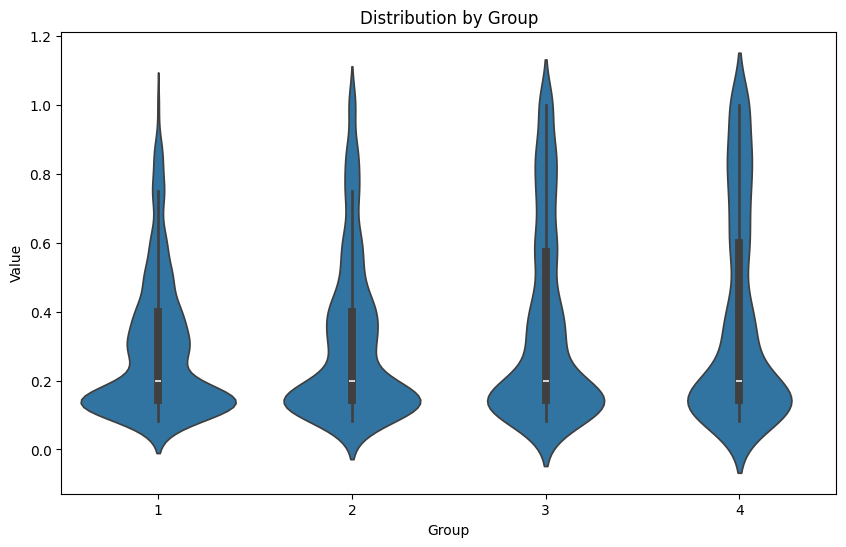

In [105]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
def plot_distribution(data_dict):
    # Convert dict to long format DataFrame
    df = pd.DataFrame([(k, v) for k, vals in data_dict.items() 
                      for v in vals], columns=['group', 'value'])
    
    # Create violin plot
    plt.figure(figsize=(10, 6))
    sns.violinplot(data=df, x='group', y='value')
    
    # Customize plot
    plt.xlabel('Group')
    plt.ylabel('Value')
    plt.title('Distribution by Group')
    
    plt.show()

# def plot_distribution(data_dict):
#     # Convert dict to long format DataFrame
#     df = pd.DataFrame([(int(k), float(v)) for k, vals in data_dict.items() 
#                       for v in vals], columns=['group', 'value'])
#     print(df)
#     # Create plot
#     plt.figure(figsize=(10, 6))
#     sns.boxplot(data=df, x='group', y='value', color='lightgray')
#     sns.swarmplot(data=df, x='group', y='value', color='darkblue', alpha=0.5)
    
#     # Customize plot
#     plt.xlabel('Group')
#     plt.ylabel('Value')
#     plt.title('Distribution by Group')
    
#     plt.show()

plot_distribution(leaves_by_q)

In [106]:
def collapse_traj(traj):
    new_traj = [traj[0]]
    for t in traj:
        if t != new_traj[-1]:
            new_traj.append(t)
    return new_traj

## Check when person leaves backbone??
by_people = {}
leaves_by_q = {1: [], 2: [], 3: [], 4: []}
for (start_node, end_node), group in test_df.groupby(["StartAt", "EndAt"]):
    backbone_path = flow_tree_dict[(start_node, end_node)]["backbone_path"]
    # print(backbone_path)
    for i, row in group.iterrows():
        subj = row["Subject"]
        traj = collapse_traj(row["paths"].split())
        # print(traj)
        on_backbone = 0
        when_leave = None
        for subj_node, back_node  in zip(traj, backbone_path):
            if subj_node == back_node[0]:
                on_backbone += 1
            else:
                when_leave = back_node[0]
                break
        leaves_by_q[row["quartile"]].append(on_backbone / len(backbone_path))
        if subj in by_people:
            by_people[subj].append(on_backbone / len(backbone_path))
        else:
            by_people[subj] = [on_backbone / len(backbone_path)]
        # print(on_backbone, when_leave)
        # print(row["subj_mean_acc"], row["quartile"])


In [107]:
for k, v in by_people:
    pri

{2: [1.0,
  0.75,
  0.875,
  1.0,
  0.8571428571428571,
  0.16666666666666666,
  0.4,
  0.8571428571428571,
  0.6,
  0.2857142857142857,
  0.2857142857142857,
  0.3333333333333333,
  0.16666666666666666,
  0.5714285714285714,
  0.8,
  0.5714285714285714,
  0.6,
  0.375,
  0.42857142857142855,
  0.3,
  0.7142857142857143,
  0.14285714285714285,
  0.1111111111111111,
  0.16666666666666666,
  0.14285714285714285,
  0.2,
  0.14285714285714285,
  0.7142857142857143,
  0.3125,
  0.4,
  0.3333333333333333,
  0.4,
  0.1,
  0.14285714285714285,
  0.14285714285714285,
  0.125,
  0.14285714285714285,
  0.8333333333333334,
  0.125,
  0.16666666666666666,
  0.14285714285714285,
  0.125,
  0.125,
  0.14285714285714285,
  0.125,
  0.16666666666666666,
  0.14285714285714285,
  0.16666666666666666],
 5: [1.0,
  0.75,
  0.375,
  1.0,
  0.8571428571428571,
  0.16666666666666666,
  0.4,
  0.8571428571428571,
  0.4,
  0.2857142857142857,
  0.5714285714285714,
  0.6666666666666666,
  0.16666666666666666,
  

In [74]:
for path, ft_info in flow_tree_dict.items():
    backbone_path = ft_info["backbone_path"]
    if ft_info["backbone_path"][-1][0] != path[1]:
        print("Backbone not correct", path, ft_info["backbone_path"], ft_info["backbone_weights"])

Backbone not correct ('P', 'Y') ['P_0', 'P_1', 'Z_0', 'T_0', 'U_0', 'W_0', 'U_1', 'R_1', 'O_0'] [67, 65, 61, 25, 13, 5, 4, 2]


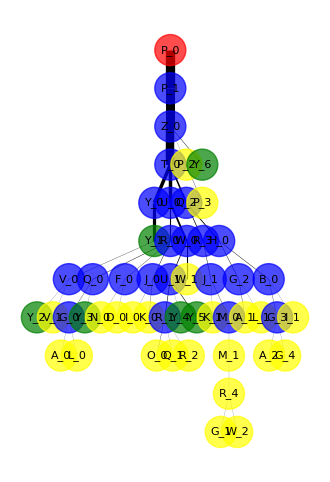

[67, 65, 61, 25, 13, 5, 4, 2]
26.88888888888889
[67, 65, 61, 25]
43.6


In [63]:
def plot_treeb(G):
    fig = plt.figure(figsize=(4,6))
    this_ax = plt.gca()

    pos = graphviz_layout(G, prog="dot")
    
    edges = G.edges()
    weights = [G[u][v]['weight'] * .1 for u,v in edges]

    nodes = G.nodes()
    # for n in nodes:
    #     print(n, G.nodes[n])
    n_labels = {n: n for n in G}
    n_colors = [G.nodes[n].get("color", "blue") for n in nodes]
    # print(n_colors)
    # print ((q-1) // 2, (q-1) % 2)
    nx.draw_networkx_nodes(G, pos, node_color=n_colors, node_size=500, alpha=0.7, ax=this_ax)
    nx.draw_networkx_edges(G, pos, edgelist=edges, width=weights, ax=this_ax)
    nx.draw_networkx_labels(G, pos, labels=n_labels, font_size=8, ax=this_ax) # font_weight="bold",

    this_ax.axis("off")
    plt.show()

tree = flow_tree_dict[("P", "Y")]["flow_tree"]
root = "P_0"
leaf = "O_0"

plot_treeb(tree)

path = nx.shortest_path(tree, root, leaf, weight='weight')
path_len = len(path)

# Calculate total weight of path
path_weight = sum(tree[path[i]][path[i+1]]['weight'] for i in range(len(path)-1)) / path_len
print([tree[path[i]][path[i+1]]['weight'] for i in range(len(path)-1)])
print(path_weight)

leaf = "Y_0"
path = nx.shortest_path(tree, root, leaf, weight='weight')
path_len = len(path)

# Calculate total weight of path
path_weight = sum(tree[path[i]][path[i+1]]['weight'] for i in range(len(path)-1)) / path_len
print([tree[path[i]][path[i+1]]['weight'] for i in range(len(path)-1)])
print(path_weight)